# Bioreactor Control: Open-Loop vs Closed-Loop Steuerung

## Überblick

Dieses Notebook demonstriert verschiedene Regelungsstrategien für einen Bioreaktors:
- **Keine Steuerung**: Vorwärtzmodellierung des Systems
- **Optimal Control (OCP)**: Optimale Steuerung über einen Zeithorizont
- **Model Predictive Control (MPC)**: Rekeding-Horizon Optimierung mit Constraints
- **PID Controller**: Klassische Rückkopplungsregelung

## Bioreactor Modell

Der Bioreactor wird durch folgende Differentialgleichungen beschrieben:

$$\frac{dX}{dt} = \frac{-F_{out} \cdot X - \frac{dV}{dt} \cdot X}{V}$$

$$\frac{dS}{dt} = \frac{F_{in} \cdot S_{in} - F_{out} \cdot S - \frac{dV}{dt} \cdot S}{V}$$

$$\frac{dV}{dt} = F_{in} - F_{out}$$

**Parameter:**
- $X$: Biomasse-Konzentration [g/L]
- $S$: Substrat-Konzentration [g/L]  
- $V$: Reaktorvolumen [m³]
- $F_{in}$: Einlassstrom (Steuerung) [m³/s]
- $F_{out}$: Auslassstrom [m³/s]
- $S_{in}$: Substratkonzentration im Feed [g/L]

Es gibt verschiedene Arten wir man einen zustand in einem Prozess erreischen kann.


1. Optimales Steuern (Optimal Control)
2. Regeln (PID Controller)
3. Regeln (Model Predictive Control)

## 1. Imports und Setup

Wir importieren die notwendigen Bibliotheken für Modellierung, Optimierung und Visualisierung.

In [2]:
import casadi as ca
# BIOREACTOR
S_in = 0.5
F_in = 1.0
F_out = 1.0

X = ca.SX.sym('X')
S = ca.SX.sym('S')
V = ca.SX.sym('V')
states = ca.vertcat(X, S, V)
n_states = 3


dV_dt = F_in - F_out
dx_dt = (-F_out * X - dV_dt * X) / V
ds_dt = (F_in * S_in - F_out * S - dV_dt * S) / V
f = ca.vertcat(dx_dt, ds_dt, dV_dt)



Happy!


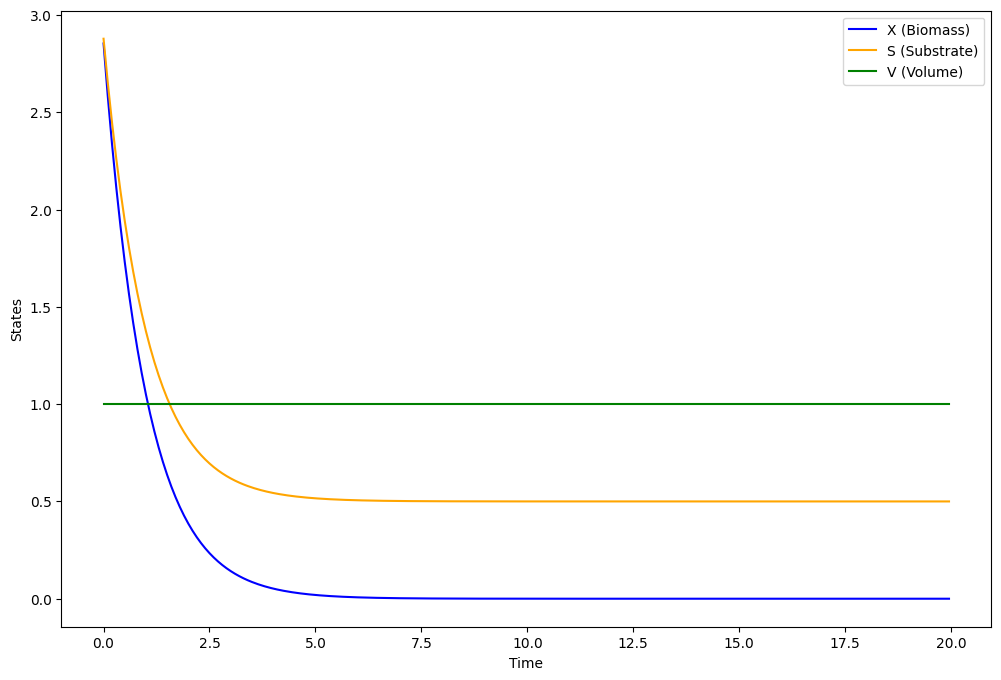

In [33]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt


# MPC Parameter und Setup
dt = 0.05
T = 20 

integrator_mpc = ca.integrator(
    "integrator_mpc", "idas",
    {"x": states, "ode": f},
    0.0, dt
)

X0 = ca.vertcat(3.0, 3.0, 1.0)  #Anfangszustand

steps = int(T / dt)
X_sim = []
S_sim = []
V_sim = []

for k in range(steps):
    
    x_k = X0 if k == 0 else res['xf']
    res = integrator_mpc(x0=x_k)
    x_k = res['xf']
    X_sim.append(x_k[0].full().flatten()[0])
    S_sim.append(x_k[1].full().flatten()[0])
    V_sim.append(x_k[2].full().flatten()[0])

# Plot Ergebnisse
time = np.linspace(0, T, steps + 1)

plt.figure(figsize=(12, 8))
plt.plot(time[:-1], X_sim, label='X (Biomass)', color='blue')
plt.plot(time[:-1], S_sim, label='S (Substrate)', color='orange')
plt.plot(time[:-1], V_sim, label='V (Volume)', color='green')
plt.xlabel('Time')
plt.ylabel('States')
plt.legend()



print("\nHappy!")

## 2. Bioreactor Modell Definition

Definiere die Zustände, Steuerungsgrößen und das dynamische Modell mit CasADi.

- **Zustände**: $X$ (Biomasse), $S$ (Substrat), $V$ (Volumen)
- **Steuerung**: $F_{in}$ (Einlassstrom)
- **ODE**: Bioreactor Differentialgleichungen

## 4. Optimal Control Problem (OCP)

Das **Optimal Control Problem** findet die beste Steuerungssequenz über einen gesamten Zeithorizont durch Minimierung einer Kostenfunktion.

**Formulierung:**

Minimize: 
$$J = \sum_{k=0}^{N-1} \left[ (x_k - x_{ref})^T Q (x_k - x_{ref}) + u_k^T R u_k \right] + 10 \cdot (x_N - x_{ref})^T Q (x_N - x_{ref})$$

Subject to:
- Dynamik: $x_{k+1} = x_k + f(x_k, u_k) \cdot dt$
- Constraints: $F_{in,min} \leq u_k \leq F_{in,max}$ und $V_{min} \leq V_k \leq V_{max}$

**Vorteile:**
- ✓ Optimal über den gesamten Horizont
- ✓ Explizite Constraints
- ✗ Rechenintensiv bei langen Horizonten

**Parameter:**
- $Q = diag([100, 1, 1])$: Gewichtung der Zustände
- $R = [0.01]$: Gewichtung der Steuerungsaufwand
- Terminal-Cost: $10 \times Q \times (x_N - x_{ref})^2$

## 3. Optimal Control (OCP)


Optimal Control Problem gelöst!


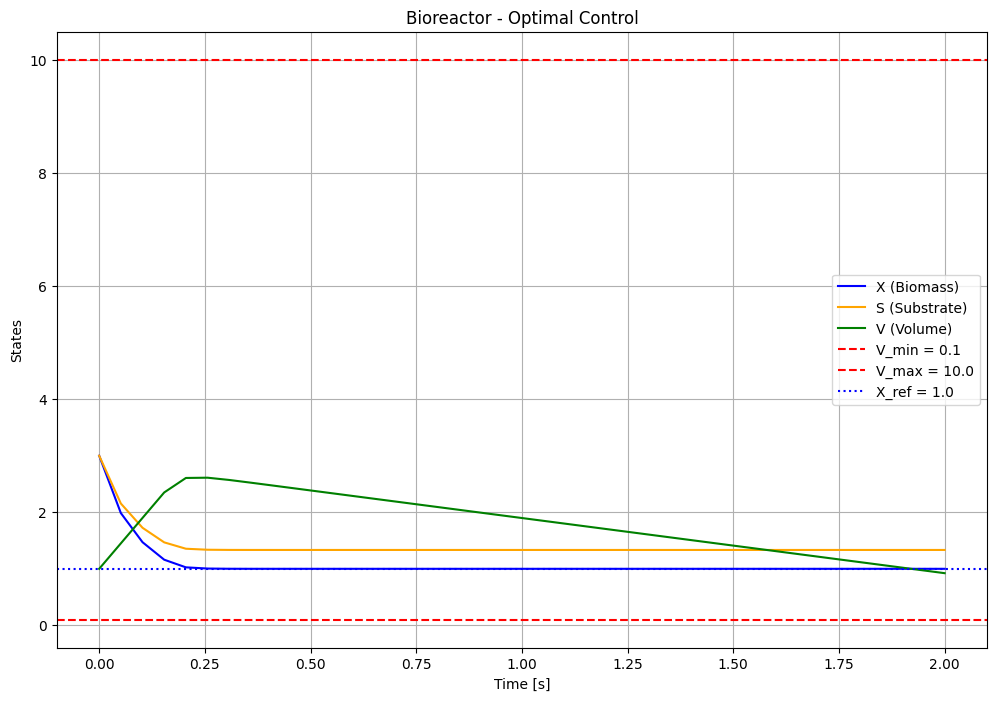

In [3]:
# Parameter
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt

# BIOREACTOR
S_in = 0.5
F_out = 1.0

X = ca.SX.sym('X')
S = ca.SX.sym('S')
V = ca.SX.sym('V')
states = ca.vertcat(X, S, V)
n_states = 3

F_in = ca.SX.sym('F_in')
controls = F_in
n_controls = 1

dV_dt = F_in - F_out
dx_dt = (-F_out * X - dV_dt * X) / V
ds_dt = (F_in * S_in - F_out * S - dV_dt * S) / V
f = ca.vertcat(dx_dt, ds_dt, dV_dt)


dt = 0.05
T = 2
N_horizont = int(T / dt)

# Integrator mit Kontrolle erstellen (wie in main.py)
integrator = ca.integrator(
    "integrator", "idas",
    {"x": states, "p": controls, "ode": f},
    0.0, dt
)

# Optimierungsvariable
U = ca.SX.sym('U', n_controls, N_horizont)
X0_param = ca.SX.sym('X0_param', n_states)
x_ref = ca.SX.sym('x_ref', n_states)

# Kostenfunktion und Constraints
cost = 0
x_k = X0_param
g = []
lbg = []
ubg = []

Q = np.diag([100.0, 0.0, 0.0])  # Gewichte für Zustände
R = np.diag([0.01])  # Gewichte für Steuerung

for k in range(N_horizont):
    # Integrator anwenden
    res = integrator(x0=x_k, p=U[:, k])
    x_k = res['xf']
    
    # Kostenfunktion: Tracking + Steuerungsaufwand
    cost += (x_k - x_ref).T @ Q @ (x_k - x_ref) + U[:, k].T @ R @ U[:, k]
    
    # Constraints: Volumen zwischen 0.1 und 10
    g.append(x_k[2])
    lbg.append(0.1)
    ubg.append(10.0)

# Terminal cost
cost += 10.0 * (x_k - x_ref).T @ Q @ (x_k - x_ref)

# NLP Problem
nlp = {
    'x': ca.reshape(U, -1, 1),
    'f': cost,
    'g': ca.vertcat(*g),
    'p': ca.vertcat(X0_param, x_ref)
}

opts = {
    'ipopt.print_level': 0,
    'print_time': 0,
    'ipopt.max_iter': 200
}
solver = ca.nlpsol('solver', 'ipopt', nlp, opts)

# Bounds für Steuerung
lbx = [0.0] * N_horizont
ubx = [10.0] * N_horizont

# Initialer Zustand und Referenz
X0_val = ca.vertcat(3.0, 3.0, 1.0)
x_ref_val = ca.vertcat(1.0, 0.5, 1.0)

# Löse Optimierungsproblem
args = {
    'lbx': lbx,
    'ubx': ubx,
    'lbg': lbg,
    'ubg': ubg,
    'x0': [1.0] * N_horizont
}
args['p'] = ca.vertcat(X0_val, x_ref_val)
res = solver(**args)

U_opt = ca.reshape(res['x'], n_controls, N_horizont)
print(f'Optimal Control Problem gelöst!')

# Simuliere System mit optimalen Steuerungen
x_k = X0_val
X_values = []
S_values = []
V_values = []
time_vec = np.linspace(0, T, N_horizont)

for k in range(N_horizont):
    X_values.append(float(x_k[0]))
    S_values.append(float(x_k[1]))
    V_values.append(float(x_k[2]))
    
    res = integrator(x0=x_k, p=U_opt[:, k])
    x_k = res['xf']

# Plot
plt.figure(figsize=(12, 8))
plt.plot(time_vec, X_values, label='X (Biomass)', color='blue')
plt.plot(time_vec, S_values, label='S (Substrate)', color='orange')
plt.plot(time_vec, V_values, label='V (Volume)', color='green')
plt.axhline(y=0.1, color='r', linestyle='--', label='V_min = 0.1')
plt.axhline(y=10.0, color='r', linestyle='--', label='V_max = 10.0')
plt.axhline(y=1.0, color='b', linestyle=':', label='X_ref = 1.0')
plt.xlabel('Time [s]')
plt.ylabel('States')
plt.legend()
plt.grid()
plt.title('Bioreactor - Optimal Control')
plt.show()

## 5. Model Predictive Control (MPC)

**Model Predictive Control (MPC)** ist eine **Closed-Loop Regelungsstrategie**, die:
- Bei jedem Zeitschritt ein Optimierungsproblem über einen zukünftigen Horizont löst
- Nur die erste optimale Steuerung anwendet
- Im nächsten Schritt mit aktualisierten Messungen neu optimiert (**Receding Horizon**)


**MPC + EnKF Workflow:**
1. Schätze aktuellen Zustand mit EnKF
2. Löse OCP über Horizont $N$ mit geschätztem Zustand
3. Wende erste optimale Steuerung an
4. Zurück zu Schritt 1

**Constraints durchgesetzt:** $V_{min} \leq V_k \leq V_{max}$ für alle Prädiktionsschritte


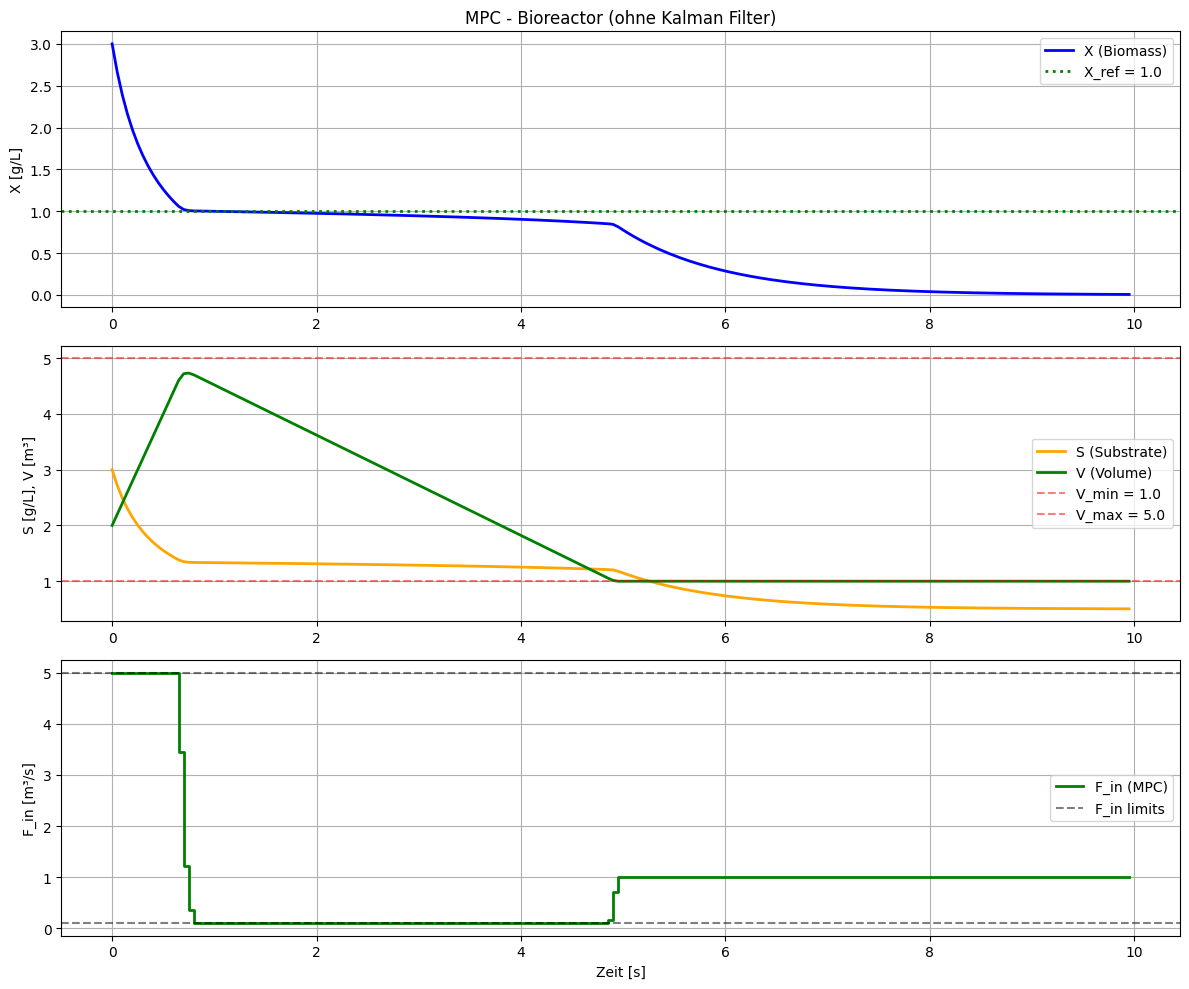

MPC Simulation abgeschlossen!
Final X: 0.0052 (Target: 1.0)
Final V: 1.0000 (Range: 1.0-5.0)


In [13]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt

# BIOREACTOR
S_in = 0.5
F_out = 1.0

X = ca.SX.sym('X')
S = ca.SX.sym('S')
V = ca.SX.sym('V')
states = ca.vertcat(X, S, V)
n_states = 3

F_in = ca.SX.sym('F_in')
controls = F_in
n_controls = 1

dV_dt = F_in - F_out
dx_dt = (-F_out * X - dV_dt * X) / V
ds_dt = (F_in * S_in - F_out * S - dV_dt * S) / V
f = ca.vertcat(dx_dt, ds_dt, dV_dt)

# MPC Parameter
dt = 0.05
N_horizont = 5
Q_mpc = np.diag([100.0, 0.0, 0.0])
R_mpc = np.diag([0.01])

F_in_min = 0.1
F_in_max = 5.0
V_min = 1.0
V_max = 5.0

integrator_mpc = ca.integrator(
    "integrator_mpc", "idas",
    {"x": states, "p": controls, "ode": f},
    0.0, dt
)

# Optimierungsvariable
U = ca.SX.sym('U', n_controls, N_horizont)
X0_param = ca.SX.sym('X0_param', n_states)
x_ref_param = ca.SX.sym('x_ref_param', n_states)

cost = 0
x_k = X0_param
g = []

for k in range(N_horizont):
    # Zustandskosten + Stellgrößenkosten
    cost += (x_k - x_ref_param).T @ Q_mpc @ (x_k - x_ref_param)
    cost += U[:, k].T @ R_mpc @ U[:, k]
    
    # Propagation
    res = integrator_mpc(x0=x_k, p=U[:, k])
    x_k = res['xf']
    
    # Volumen-Constraint
    g.append(x_k[2])

# Terminalkosten
cost += 10.0 * (x_k - x_ref_param).T @ Q_mpc @ (x_k - x_ref_param)

nlp = {
    'x': ca.reshape(U, -1, 1),
    'f': cost,
    'g': ca.vertcat(*g),
    'p': ca.vertcat(X0_param, x_ref_param)
}

opts = {
    'ipopt.print_level': 0,
    'print_time': 0,
    'ipopt.max_iter': 200
}
solver = ca.nlpsol('solver', 'ipopt', nlp, opts)

lbx = [F_in_min] * N_horizont
ubx = [F_in_max] * N_horizont
lbg = [V_min] * N_horizont
ubg = [V_max] * N_horizont

# SIMULATION
T_sim = 10.0
time = np.arange(0, T_sim, dt)

x_true = np.array([3.0, 3.0, 2.0])
X_ref = 1.0
S_ref = 1.0

X_true_hist = [x_true.copy()]
U_hist = []
time_sim = []

# Warm-Start
U_last = np.ones(N_horizont) * 1.0

for i, t in enumerate(time):
    time_sim.append(t)
    
    # Sollwert
    x_ref_val = np.array([X_ref, S_ref, 1.0])
    
    # Warm-Start: Verschiebe letzte Lösung
    x0_warm = np.concatenate([U_last[1:], [U_last[-1]]])
    
    p_val = np.concatenate([x_true, x_ref_val])
    
    try:
        sol = solver(
            x0=x0_warm,
            lbx=lbx, ubx=ubx,
            lbg=lbg, ubg=ubg,
            p=p_val
        )
        
        u_opt = np.array(sol['x']).flatten()
        U_last = u_opt
        u_apply = u_opt[0]
    except Exception as e:
        print(f"MPC failed at t={t}: {e}, using last control")
        u_apply = U_last[0]
    
    U_hist.append(u_apply)
    
    # System propagieren
    res = integrator_mpc(x0=ca.DM(x_true), p=ca.DM([u_apply]))
    x_true = np.array(res['xf']).flatten()
    X_true_hist.append(x_true.copy())

# Arrays konvertieren
X_true_hist = np.array(X_true_hist)
U_hist = np.array(U_hist)

# PLOT
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(time_sim, X_true_hist[:-1, 0], 'b-', linewidth=2, label='X (Biomass)')
axes[0].axhline(y=X_ref, color='g', linestyle=':', linewidth=2, label='X_ref = 1.0')
axes[0].set_ylabel('X [g/L]')
axes[0].legend()
axes[0].grid()
axes[0].set_title('MPC - Bioreactor (ohne Kalman Filter)')

axes[1].plot(time_sim, X_true_hist[:-1, 1], 'orange', linewidth=2, label='S (Substrate)')
axes[1].plot(time_sim, X_true_hist[:-1, 2], 'green', linewidth=2, label='V (Volume)')
axes[1].axhline(V_min, color='r', linestyle='--', alpha=0.5, label='V_min = 1.0')
axes[1].axhline(V_max, color='r', linestyle='--', alpha=0.5, label='V_max = 5.0')
axes[1].set_ylabel('S [g/L], V [m³]')
axes[1].legend()
axes[1].grid()

axes[2].step(time_sim, U_hist, 'g-', where='post', linewidth=2, label='F_in (MPC)')
axes[2].axhline(F_in_min, color='k', linestyle='--', alpha=0.5, label='F_in limits')
axes[2].axhline(F_in_max, color='k', linestyle='--', alpha=0.5)
axes[2].set_ylabel('F_in [m³/s]')
axes[2].set_xlabel('Zeit [s]')
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

print("MPC Simulation abgeschlossen!")
print(f"Final X: {X_true_hist[-1, 0]:.4f} (Target: {X_ref})")
print(f"Final V: {X_true_hist[-1, 2]:.4f} (Range: {V_min}-{V_max})")

## 6. PID Controller

Ein **PID Controller** ist eine klassische **Closed-Loop Regelungsstrategie**, die kontinuierlich:
- Den Fehler zwischen Sollwert und Istwert misst
- Die Steuerung basierend auf drei Komponenten anpasst

**PID-Gleichung:**

$$u(t) = K_p \cdot e(t) + K_i \int_0^t e(\tau) d\tau + K_d \frac{de(t)}{dt}$$

mit Fehler $e(t) = x_{ref} - x(t)$

**Komponenten:**
- **Proportional (P)**: $K_p \cdot e$ → Schnelle Reaktion auf aktuellen Fehler
- **Integral (I)**: $K_i \int e$ → Beseitigung von stationären Abweichungen
- **Derivative (D)**: $K_d \frac{de}{dt}$ → Dämfung von Überschwingern und Stabilisierung

**Regelgesetz (diskret):**
```
error = x_ref - x
error_integral += error * dt
error_derivative = (error - error_prev) / dt
u = Kp * error + Ki * error_integral + Kd * error_derivative
u = clip(u, u_min, u_max)
```

**Vorteile und Nachteile:**
- ✓ Einfach und robust
- ✓ Keine Modellierung notwendig
- ✗ Keine Vorhersage zukünftiger Zustände
- ✗ Schwieriger zu tunen (3 Parameter!)
- ✗ Lineare Regelung → nicht optimal für nichtlineare Systeme

**Typische Tuning-Strategie (Ziegler-Nichols):**
1. Setze $K_i = K_d = 0$, erhöhe $K_p$ bis Oszillation
2. Nutze Oszillationsfrequenz zur Berechnung der anderen Gains

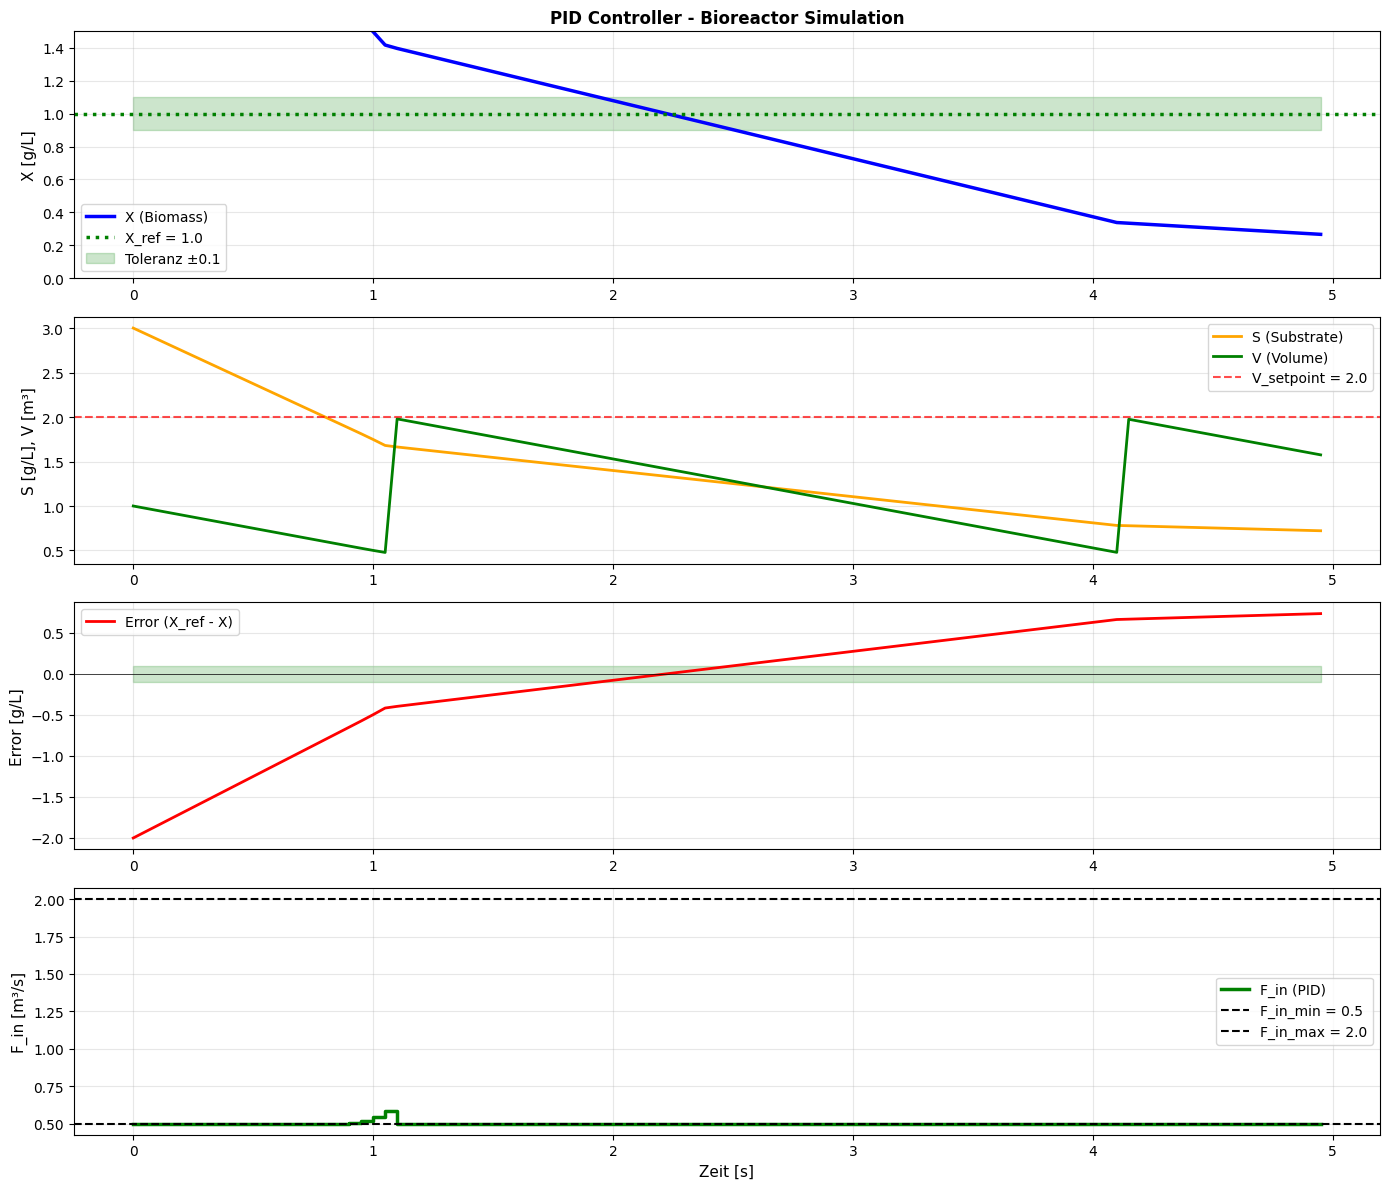

PID Controller Simulation - Ergebnisse
Initialer X: 3.0000 g/L
Finaler X:   0.2662 g/L (Target: 1.0)
Fehler:      0.7338 g/L
Min X:       0.2662 g/L
Max X:       3.0000 g/L
Avg X:       1.0666 g/L

Volumen-Range: 0.48 - 1.98 m³
Min F_in:    0.5000 m³/s
Max F_in:    0.5829 m³/s


In [ ]:
# PID controller
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt

# BIOREACTOR
S_in = 0.5
F_out = 1.0

X = ca.SX.sym('X')
S = ca.SX.sym('S')
V = ca.SX.sym('V')
states = ca.vertcat(X, S, V)
n_states = 3

F_in = ca.SX.sym('F_in')
controls = F_in
n_controls = 1

dV_dt = F_in - F_out
dx_dt = (-F_out * X - dV_dt * X) / V
ds_dt = (F_in * S_in - F_out * S - dV_dt * S) / V
f = ca.vertcat(dx_dt, ds_dt, dV_dt)

# Integrator
dt = 0.05
T = 5.0
n_steps = int(T / dt)

integrator = ca.integrator(
    "integrator", "idas",
    {"x": states, "p": controls, "ode": f},
    0.0, dt
)

# PID Parameter - sanfter tuned
Kp = 0.15   # Noch niedriger - sehr sanft
Ki = 0.001  # Sehr klein
Kd = 0.4  # Minimal
Integral_max = 0.5  # Anti-Windup begrenzen

X_ref = 1.0
F_in_min = 0.5  # Mindestflussrate erhöht!
F_in_max = 2.0  # Maximale Flussrate reduziert!

# Initialer Zustand - stabilere Startwerte
x_k = np.array([3.0, 3.0, 1.0])

# PID State
error_integral = 0.0
error_prev = 0.0

# Speichern für Visualisierung
X_values = []
S_values = []
V_values = []
U_values = []
error_values = []
time_vec = []

for k in range(n_steps):
    # Aktuelle Zeit speichern
    time_vec.append(k * dt)
    
    # Zustand speichern
    X_values.append(x_k[0])
    S_values.append(x_k[1])
    V_values.append(x_k[2])
    
    # **Sicherheitsprüfung: Volumen muss positiv sein**
    if x_k[2] < 0.5:
        print(f"WARNING: Volume too small at t={k*dt:.2f}s: V={x_k[2]:.4f}, resetting to 2.0")
        x_k[2] = 2.0
    
    # PID Regelung
    error = X_ref - x_k[0]
    error_values.append(error)
    
    # Integrale mit Anti-Windup
    error_integral += error * dt
    error_integral = np.clip(error_integral, -Integral_max, Integral_max)
    
    # Derivative
    error_derivative = (error - error_prev) / dt if k > 0 else 0.0
    
    # PID-Stellgröße
    u = Kp * error + Ki * error_integral + Kd * error_derivative
    
    # Begrenzung der Steuerung - WICHTIG!
    u = np.clip(u, F_in_min, F_in_max)
    
    U_values.append(u)
    
    # System propagieren - mit error handling
    try:
        res = integrator(x0=ca.DM(x_k), p=ca.DM([u]))
        x_k_new = np.array(res['xf']).flatten()
        
        # **Prüfe auf NaN oder Inf**
        if np.any(np.isnan(x_k_new)) or np.any(np.isinf(x_k_new)):
            print(f"WARNING: NaN/Inf detected at t={k*dt:.2f}s, keeping last valid state")
            # Behalte letzten gültigen Zustand
        else:
            x_k = x_k_new
    except Exception as e:
        print(f"Integration failed at t={k*dt:.2f}s: {e}")
        break
    
    # Für nächsten Schritt
    error_prev = error

# Plot
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# X Regelung
axes[0].plot(time_vec, X_values, 'b-', linewidth=2.5, label='X (Biomass)')
axes[0].axhline(y=X_ref, color='g', linestyle=':', linewidth=2.5, label='X_ref = 1.0')
axes[0].fill_between(time_vec, X_ref-0.1, X_ref+0.1, alpha=0.2, color='green', label='Toleranz ±0.1')
axes[0].set_ylabel('X [g/L]', fontsize=11)
axes[0].set_ylim([0, 1.5])
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].set_title('PID Controller - Bioreactor Simulation', fontsize=12, fontweight='bold')

# S und V
axes[1].plot(time_vec, S_values, 'orange', linewidth=2, label='S (Substrate)')
axes[1].plot(time_vec, V_values, 'green', linewidth=2, label='V (Volume)')
axes[1].set_ylabel('S [g/L], V [m³]', fontsize=11)
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

# Fehler
axes[2].plot(time_vec, error_values, 'r-', linewidth=2, label='Error (X_ref - X)')
axes[2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[2].fill_between(time_vec, -0.1, 0.1, alpha=0.2, color='green')
axes[2].set_ylabel('Error [g/L]', fontsize=11)
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)

# Steuerung
axes[3].step(time_vec, U_values, 'g-', where='post', linewidth=2.5, label='F_in (PID)')
axes[3].axhline(y=F_in_min, color='k', linestyle='--', linewidth=1.5, label=f'F_in_min = {F_in_min}')
axes[3].axhline(y=F_in_max, color='k', linestyle='--', linewidth=1.5, label=f'F_in_max = {F_in_max}')
axes[3].set_ylabel('F_in [m³/s]', fontsize=11)
axes[3].set_xlabel('Zeit [s]', fontsize=11)
axes[3].legend(loc='best')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiken
print("=" * 50)
print("PID Controller Simulation - Ergebnisse")
print("=" * 50)
print(f"Initialer X: {X_values[0]:.4f} g/L")
print(f"Finaler X:   {X_values[-1]:.4f} g/L (Target: {X_ref})")
print(f"Fehler:      {abs(X_values[-1] - X_ref):.4f} g/L")
print(f"Min X:       {min(X_values):.4f} g/L")
print(f"Max X:       {max(X_values):.4f} g/L")
print(f"Avg X:       {np.mean(X_values):.4f} g/L")
print()
print(f"Volumen-Range: {min(V_values):.2f} - {max(V_values):.2f} m³")
print(f"Min F_in:    {min(U_values):.4f} m³/s")
print(f"Max F_in:    {max(U_values):.4f} m³/s")
print("=" * 50)

## Vergleich der Regelungsstrategien

| Strategie | OCP | MPC | PID |
|-----------|-----|-----|-----|
| **Feedback** | ✗ | ✓ | ✓ |
| **Optimalität** | ✓ Global | ✓ Lokal | ✗ |
| **Horizont** | Fest | Rekeding | Augenblicklich |
| **Constraints** | ✓ | ✓ | ~ Begrenzung |
| **Rechenkomplexität** |  O(N³) | O(N³)/Step | O(1) |
| **Robustheit** |  Mittel | Hoch | Hoch |
| **Unsicherheit** | ✗ | ✓ (EnKF) | ✓ Implizit |
| **Praktisch** | Offline-Planung | **Industrial-Standard** | **Sehr häufig** |

**Fazit:**
- **OCP**: Offline-Planung oder Trajektorien
- **MPC**: Moderne Regelung mit Unsicherheitsquantifizierung
- **PID**: Robustes Workhorse für industrielle Anwendungen